# Inference Time Study

In [17]:
################################################## Initialize ##################################################

# Add the new path
import sys
new_path = "/home/michele/code/michele_mmdet3d/"
if not new_path in sys.path:
    sys.path.insert(1, new_path)



############################################# Time-related variables #############################################
import time
import torch
if not torch.cuda.is_available():
    raise MemoryError("\t\tCUDA not available: exiting...\n\n\n")

delta_preprocessing = []
delta_inference = []
delta_postprocessing = []

In [18]:
############################################### Generic Parameters ###############################################

# Boolean to print inputs/outputs of each stage
wanna_print_in_out = False

# Home directory within ADE
home_dir = '/home/michele/code/'

# Relative path from "home_dir" to the .bin files
path_from_home_to_bin_files = "michele_mmdet3d/data/minerva_polimove_cones_augmented/training/velodyne"
# Path to the ".txt" file in "ImageSets", containing the list of validation files
val_list_txt_file = "/home/michele/code/michele_mmdet3d/data/minerva_polimove_cones_augmented/ImageSets/val.txt"
# Path to the .pkl file for the validation dataset (saved during create_data.py)
pkl_info_file = "/home/michele/code/michele_mmdet3d/data/minerva_polimove_cones_augmented/minerva_polimove_cones_augmented_infos_val.pkl"

# Boolean to choose the type of model ("TensorRT" or "PyTorch")
# model_type = "Tensor-RT"
model_type = "PyTorch"



############################################# Configuration Parameters #############################################



# # Case 0: PointPillars
# #         HardVoxelization  (Deterministic or Non-Deterministic voxelization can be chosen in the config)
# #         TRT
# #         (@ epoch 61)
# # 
# mmdet3d_cfg = home_dir + 'michele_mmdet3d/configs/minerva/CONDENSED-HARD_pointpillars_minerva.py'
# # Specific for Tensor-RT
# if model_type == "Tensor-RT":
#     deploy_cfg = home_dir + 'mmdeploy/configs/mmdet3d/voxel-detection/voxel-detection_tensorrt_dynamic-kitti-32x4.py'
#     engine_files = [ home_dir + 'Presentation_results/PPillars_Checkpoints/PPillars_HardVox/mmdeploy_model/PointPillars_Hard.engine' ]
#     reference_img = home_dir + 'auto-labeling/data/Databases/Merged_Fusion_DataSet/MMDetection3D Version "Whole PCD No Images"/training/velodyne/1722779447121733104.bin'
# # Specific for PyTorch
# if model_type == "PyTorch":
#     weights = home_dir + 'Presentation_results/PPillars_Checkpoints/PPillars_HardVox/Checkpoints/epoch_61.pth'



# # Case 1: PointPillars
# #         DynamicVoxelization 
# #         (@ epoch 57)
# # 
# mmdet3d_cfg = home_dir + 'michele_mmdet3d/configs/minerva/CONDENSED-DYNAMIC_pointpillars_minerva.py'
# # Specific for Tensor-RT
# if model_type == "Tensor-RT":
#     deploy_cfg = home_dir + ''
#     engine_files = [ home_dir + '' ]
#     reference_img = home_dir + ''
# # Specific for PyTorch
# if model_type == "PyTorch":
#     weights = home_dir + 'Presentation_results/PPillars_Checkpoints/PPillars_DynamicVox/Checkpoint/epoch_57.pth'



# # Case 2: Cone-Shaped
# #         DynamicVoxelization
# #         (@ epoch 110)
# # 
# mmdet3d_cfg = home_dir + 'michele_mmdet3d/configs/minerva/CONE-SHAPED-DYNAMIC_pointpillars_minerva.py'
# # Specific for Tensor-RT
# if model_type == "Tensor-RT":
#     deploy_cfg = home_dir + ''
#     engine_files = [ home_dir + '' ]
#     reference_img = home_dir + ''
# # Specific for PyTorch
# if model_type == "PyTorch":
#     weights = home_dir + 'Presentation_results/PPillars_Checkpoints/Cone-Shaped_DynamicVox/Checkpoints/epoch_110.pth'



# # Case 3: Cone-Augmented
# #         HardVoxelization
# #         TRT
# #         (@ epoch 55)
# # 
# mmdet3d_cfg = home_dir + 'michele_mmdet3d/configs/minerva/CONE-AUGMENTED-HARD_pointpillars_minerva.py'
# # Specific for Tensor-RT
# if model_type == "Tensor-RT":
#     deploy_cfg = home_dir + 'mmdeploy/configs/mmdet3d/voxel-detection/voxel-detection_tensorrt_dynamic-kitti-32x4_augmented.py'
#     engine_files = [ home_dir + 'Presentation_results/PPillars_Checkpoints/Cone-Augmented_HardVox/TRT engines/Cone-Augmented_Hard.engine' ]
#     reference_img = home_dir + 'auto-labeling/data/Databases/Merged_Fusion_DataSet/MMDetection3D Version "Whole PCD No Images"/training/velodyne/1722779447121733104.bin'
# # Specific for PyTorch
# if model_type == "PyTorch":
#     weights = home_dir + 'Presentation_results/PPillars_Checkpoints/Cone-Augmented_HardVox/Checkpoints/epoch_55.pth'



# Case 4: Cone-Augmented
#         DynamicVoxelization
#         (@ epoch 83)
# 
mmdet3d_cfg = home_dir + 'michele_mmdet3d/configs/minerva/CONE-AUGMENTED-DYNAMIC_pointpillars_minerva.py'
# Specific for Tensor-RT
if model_type == "Tensor-RT":
    deploy_cfg = home_dir + ''
    engine_files = [ home_dir + '' ]
    reference_img = home_dir + ''
# Specific for PyTorch
if model_type == "PyTorch":
    weights = home_dir + 'Presentation_results/PPillars_Checkpoints/Cone-Augmented_DynamicVox/Checkpoints/epoch_83.pth'

In [19]:
################################################ Create the model ################################################
from mmdeploy.apis.inference import get_model
from mmdet3d.apis import LidarDet3DInferencer



if model_type == "Tensor-RT":
    # Build the model with the built-in function of MMDeploy
    model = get_model(
        model_cfg= mmdet3d_cfg,
        deploy_cfg= deploy_cfg,
        backend_files= engine_files,
        img= reference_img,
        device='cuda')
    model_cfg = model.model_cfg

elif model_type == "PyTorch":
    # Get the model from the inferencer
    inferencer = LidarDet3DInferencer(model= mmdet3d_cfg,
                                      weights= weights,
                                      device= 'cuda',
                                      show_progress=False)
    model_cfg = inferencer.cfg
    model = inferencer.model



# Build the additional BBoxHead (for PointPillars)
from mmengine.registry import MODELS
bbox_head = MODELS.build(model_cfg.model).bbox_head.to('cuda:0')

Loads checkpoint by local backend from path: /home/michele/code/Presentation_results/PPillars_Checkpoints/Cone-Augmented_DynamicVox/Checkpoints/epoch_83.pth


In [20]:
############################################### Automatic configs ###############################################

config_dictionary = {}

# For the loader
config_dictionary['LoadPointsFromFile'] = {
    'coord_type': model_cfg.val_dataloader.dataset.pipeline[0].coord_type,
    'load_dim': model_cfg.val_dataloader.dataset.pipeline[0].load_dim,
    'use_dim': model_cfg.val_dataloader.dataset.pipeline[0].use_dim
}

# For the Det3DDataPreprocessor
config_dictionary['Det3DDataPreprocessor'] = {
    'voxel': model_cfg.model.data_preprocessor.voxel,
    'voxel_layer': dict(
        max_num_points = model_cfg.model.data_preprocessor.voxel_layer.max_num_points,
        max_voxels = model_cfg.model.data_preprocessor.voxel_layer.max_voxels,
        point_cloud_range = model_cfg.model.data_preprocessor.voxel_layer.point_cloud_range,
        voxel_size = model_cfg.model.data_preprocessor.voxel_layer.voxel_size
    ),
    'voxel_type': model_cfg.model.data_preprocessor.voxel_type
}

# For the BBoxHead (which needs the test configuration)
config_dictionary['test_cfg'] = model_cfg['model']['test_cfg']

In [21]:
############################################### Very original input ###############################################

# Read the names of the validation files from the ".txt" file in "ImageSets"
with open(val_list_txt_file, 'r') as file:
    val_file_names = [line.strip()+".bin" for line in file]



# Create the inputs
#   - List of strings
#   - Each string is the ABSOLUTE path to the ".bin" file
inputs = []
for file_name in val_file_names:
    inputs.append(home_dir+path_from_home_to_bin_files+"/"+file_name)



# Print the output of this stage
if wanna_print_in_out:
    print("\nStarting values:")
    for element in inputs:
        print(element)

In [22]:
############################################### LoadPointsFromFile ###############################################

from mmdet3d.datasets.transforms.loading import LoadPointsFromFile

# Initialize the loader
loader = LoadPointsFromFile(
    coord_type=config_dictionary['LoadPointsFromFile']['coord_type'],
    load_dim=config_dictionary['LoadPointsFromFile']['load_dim'],
    use_dim=config_dictionary['LoadPointsFromFile']['use_dim']
)

# Print the input to this stage
if wanna_print_in_out:
    print("\nLoadPointsFromFile input:")
    for element in inputs:
        print(element)



# For cycle to also handle lists of inputs
for i in range(len(inputs)):
    
    # Prepare the string input for the loader (needs two dictionaries, one nested into the other)
    inputs[i] = dict(
        lidar_points=dict(
            lidar_path=inputs[i]
        )
    )

    # Actual modification of the dictionary
    loader(inputs[i])



# Print the output of this stage
if wanna_print_in_out: 
    print("\nLoadPointsFromFile output:")
    for element in inputs:
        print(element)

In [23]:
############################################### Add METAINFO ###############################################

import mmengine
from mmdet3d.structures.bbox_3d import Box3DMode, LiDARInstance3DBoxes

# Print the input of this stage
if wanna_print_in_out: 
    print("\nBefore adding metainfos:")
    for element in inputs:
        print(element)

# Get the METAINFO from the .pkl file
info_list = mmengine.load(pkl_info_file)['data_list']



# Check the format of info_list, and make it match inputs
new_info_list = []
if not len(info_list) == len(inputs):
    # Copied from MultiModalityDet3DInferencer._inputs_to_list()
    for element in inputs:
        timestamp = element['lidar_points']['lidar_path'].split('/')[-1].split('.')[0]
        for element in info_list:
            if str(element['sample_idx']) == str(timestamp):
                new_info_list.append(element)
    # Update the field "info_list"    
    info_list = new_info_list



# Get the right fields
for index, input in enumerate(inputs):
    data_info = info_list[index]
    input['box_mode_3d'] = Box3DMode.LIDAR
    input['box_type_3d'] = LiDARInstance3DBoxes

# Print the output of this stage
if wanna_print_in_out: 
    print("\nAfter adding metainfos:")
    for element in inputs:
        print(element)

In [24]:
############################################### Pack3DDetInputs ###############################################

from mmdet3d.datasets.transforms.formating import Pack3DDetInputs

# Initialize the packer
packer = Pack3DDetInputs(keys=['points'])

# Print the input to this stage
if wanna_print_in_out: 
    print("\nPack3DDetInputs input:")
    for element in inputs:
        print(element)



# For cycle to also handle lists of inputs
for i in range(len(inputs)):
    
    # Actual modification of the dictionary
    inputs[i] = packer(inputs[i])



# Print the output of this stage
if wanna_print_in_out: 
    print("\nPack3DDetInputs output:")
    for element in inputs:
        print(element)

In [25]:
############################################### Det3DDataPreprocessor ###############################################

from mmdet3d.models.data_preprocessors.data_preprocessor import Det3DDataPreprocessor

# Initialize the preprocessor
preprocessor = Det3DDataPreprocessor(
    voxel=config_dictionary['Det3DDataPreprocessor']['voxel'],
    voxel_layer=config_dictionary['Det3DDataPreprocessor']['voxel_layer'],
    voxel_type=config_dictionary['Det3DDataPreprocessor']['voxel_type']
)

# Print the input to this stage
if wanna_print_in_out: 
    print("\nDet3DDataPreprocessor input:")
    for element in inputs:
        print(element)



# Create the list with the final inputs
final_inputs = []
for i in range(len(inputs)):    

    # Create a temporary dictionary to be passed to the preprocessor (in the right format)
    temp = {
        'data_samples': [inputs[i]['data_samples']],
        'inputs': inputs[i]['inputs']}
    temp['inputs']['points'] = [inputs[i]['inputs']['points']]

    # Take out the result of the Det3DDataPreprocessor, and also compute the time
    start_preprocessing = time.time()
    final_inputs.append(
        preprocessor(temp))
    torch.cuda.synchronize()
    end_preprocessing = time.time()
    # Append the time to the right list
    delta_preprocessing.append(end_preprocessing-start_preprocessing)



# Move the tensors to the right device
for element in final_inputs:
    element['inputs']['points'][0] = element['inputs']['points'][0].to('cuda:0')
    element['inputs']['voxels']['voxels'] = element['inputs']['voxels']['voxels'].to('cuda:0')
    element['inputs']['voxels']['coors'] = element['inputs']['voxels']['coors'].to('cuda:0')

# Print the output of this stage
if wanna_print_in_out: 
    print("\nDet3DDataPreprocessor output:")
    for element in final_inputs:
        print(element)

In [26]:
############################################ Inference and Post-Processing ############################################

predictions=[]
for element in final_inputs:

    # Inference
    torch.cuda.synchronize()
    start_inference = time.time()
    raw_results = model(element['inputs'], mode='tensor')
    torch.cuda.synchronize()
    end_inference = time.time()
    delta_inference.append(end_inference-start_inference)

    # Unpack the raw data
    if model_type == "Tensor-RT":
        cls_score = raw_results['cls_score']
        bbox_pred = raw_results['bbox_pred']
        dir_cls_pred = raw_results['dir_cls_pred']
    elif model_type == "PyTorch":
        cls_score = raw_results[0]
        bbox_pred = raw_results[1]
        dir_cls_pred = raw_results[2]

    # Post-processing
    predictions.append(
        bbox_head.predict_by_feat(
            cls_scores = cls_score,
            bbox_preds = bbox_pred,
            dir_cls_preds = dir_cls_pred,
            batch_input_metas = [element['data_samples'][0].metainfo],
            cfg = config_dictionary['test_cfg']))
    torch.cuda.synchronize()
    end_postprocessing = time.time()
    delta_postprocessing.append(end_postprocessing-end_inference)

    # Reset all the tensors for memory reasons
    raw_results = None
    cls_score = None
    bbox_pred = None
    dir_cls_pred = None



# Print the output of this stage
if wanna_print_in_out: 
    print("\nFinal predictions:")
    for element in predictions:
        print(element)

In [27]:
#################################################################################################################
#                                            PLOTTING OF FREQUENCY                                              #
#################################################################################################################

from demo.plotters import *

# Check that the vectors are all of the same dimension
if len(delta_preprocessing) != len(delta_postprocessing) or len(delta_preprocessing) != len(delta_inference):
    print("\nWrong dimensions for lists!!!\n")
    exit()



# Create the vector with the TOTAL delta_time
delta_total = []
for i in range(len(delta_preprocessing)):
    delta_total.append(delta_preprocessing[i]+delta_inference[i]+delta_postprocessing[i])

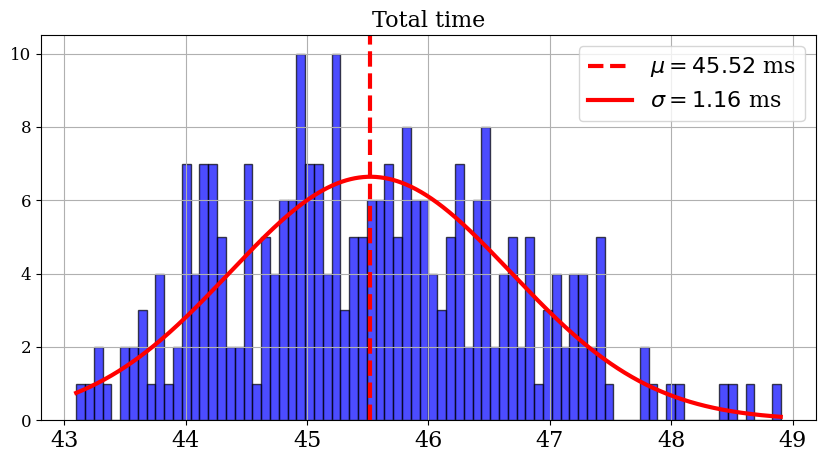

In [28]:
# Plot the total time

freq_plot_with_gaussian(delta_total, "Total time", "blue")

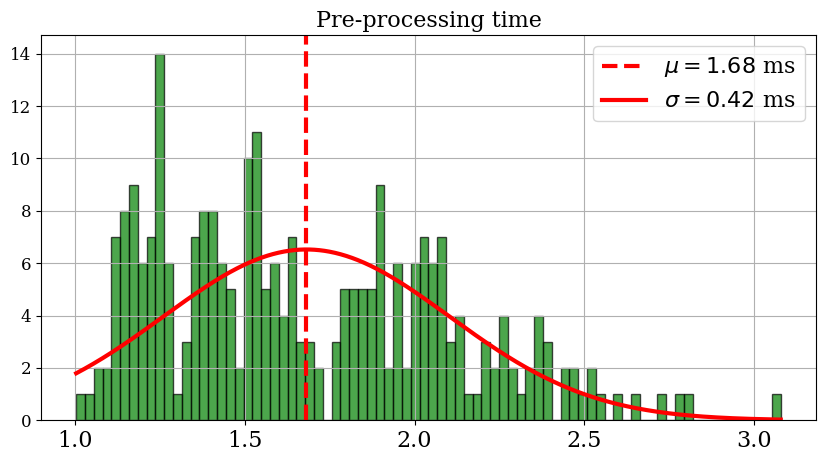

In [29]:
# Plot the pre-processing time

freq_plot_with_gaussian(delta_preprocessing, "Pre-processing time", "green")

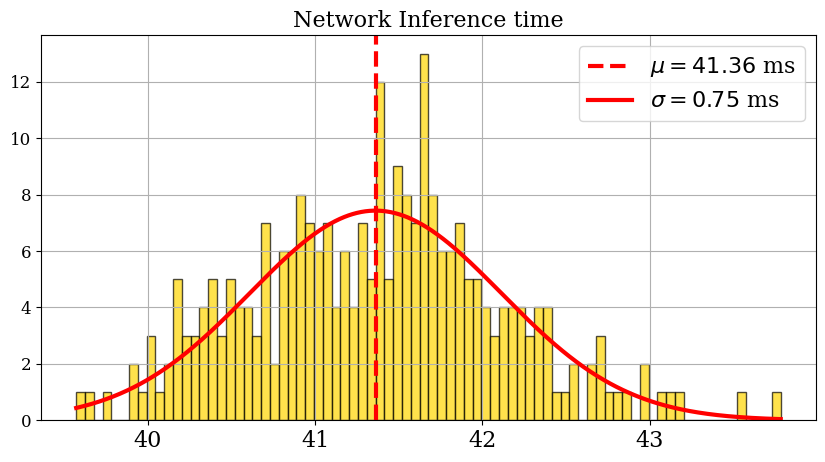

In [30]:
#Plot the inference time

freq_plot_with_gaussian(delta_inference, "Network Inference time", "gold")

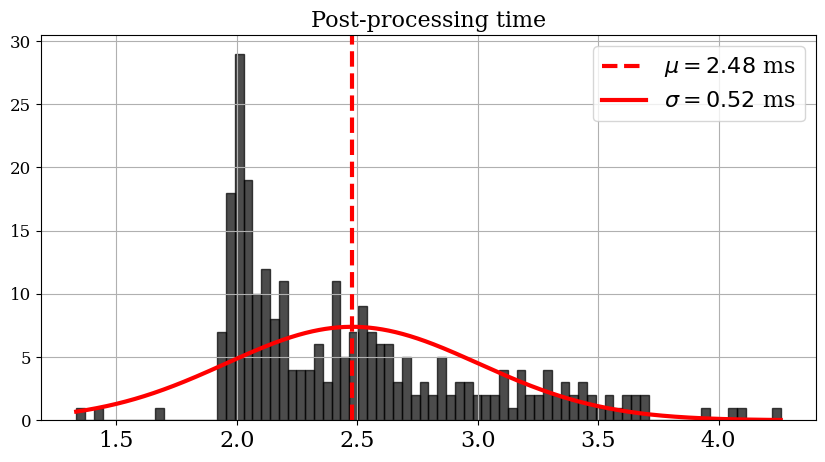

In [31]:
# Plot the post-processing time

freq_plot_with_gaussian(delta_postprocessing, "Post-processing time", "black", 80)

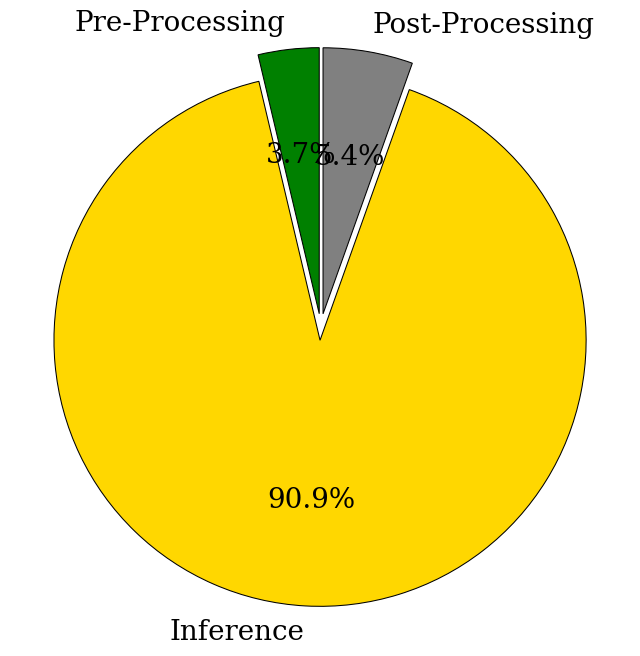

In [32]:
# Plot the pie chart with the percentages

plot_pie_chart(delta_preprocessing, delta_inference, delta_postprocessing, "Pre-Processing", "Inference", "Post-Processing")